# Illustration of the preconditioned matrix

Consider the quadratic program with equality constraints:

$$
\begin{aligned}
    \min_{x \in \mathbb{R}^2}\  & x^\top Q x + p^\top x \\
    \text{s.t.}\                & Lx = \mathbf{0},
\end{aligned}
$$\

where

$$
Q = \begin{bmatrix} 0.1 & 0 \\ 0 & 0.8 \end{bmatrix},\
L = \begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix},\
p = \begin{bmatrix} -0.45 \\ -0.45 \end{bmatrix}.
$$

This instantiates with solution $x^* = (0.5, 0.5)$.

Define preconditioning matrices:

$$
\begin{align*}
    B_1 & = I,          & \hat{g}_1(x) & = \hat{f}(\sqrt{B_1}x) \\
    B_2 & = I - 0.25L,  & \hat{g}_2(x) & = \hat{f}(\sqrt{B_2}x) \\
    B_3 & = I - 0.499L, & \hat{g}_3(x) & = \hat{f}(\sqrt{B_3}x)
\end{align*}
$$

The following figures show their level sets: decreasing non-unity eigenvalues of $B_i$ enhance alignment orthogonally to $x_1 = x_2$.

Implementing the proposed algorithm with $X^{(0)} = (-0.5, -0.5)$, $Y^{(0)} = (0, 0)$, and parameters $A = I - 0.499L$, $C = (0.12L)^2$, $\gamma = 0.5$, we test $B \in \{B_1, B_2, B_3\}$. Trajectories demonstrate improved consensus (smaller $B$ eigenvalues) accelerates convergence.

In [1]:
import numpy as np
import numpy.typing as npt
import scipy.linalg as spl

# Illustration of the function of preconditioned matrix B
L = np.array([[1, -1], [-1, 1]])
E = np.eye(2)

B_list = [E, E - L * 0.25, E - L * 0.499]
sqrt_B_list = [np.asarray(spl.sqrtm(B_i)) for B_i in B_list]

Q: npt.NDArray[np.float64] = np.diag([0.1, 0.8])
Q_list = [sqrt_B_i @ Q @ sqrt_B_i for sqrt_B_i in sqrt_B_list]

p = np.array([-0.45, -0.45])
p_list = [sqrt_B_i @ p for sqrt_B_i in sqrt_B_list]

x = np.linspace(-0.6, 0.8, 2000)
y = np.linspace(-0.6, 0.8, 2000)
X: npt.NDArray[np.float64]
Y: npt.NDArray[np.float64]
X, Y = np.meshgrid(x, y)


def compute_z(
    qmat: npt.NDArray[np.float64], pvec: npt.NDArray[np.float64]
) -> npt.NDArray[np.float64]:
    return (
        qmat[0, 0] * X**2
        + (qmat[0, 1] + qmat[1, 0]) * X * Y
        + qmat[1, 1] * Y**2
        + pvec[0] * X
        + pvec[1] * Y
    )


Z: npt.NDArray[np.float64] = compute_z(Q, p)
Z_list: list[npt.NDArray[np.float64]] = [
    compute_z(Q_i, p_i) for Q_i, p_i in zip(Q_list, p_list)
]

T = 20
gamma = 0.5

A = E - 0.499 * L
sqrt_C = 0.12 * L

xx_ini = np.array([[-0.5, -0.5]])
xx_list = [np.tile(xx_ini, (T, 1)) for _ in range(3)]
yy_list = [np.zeros((T, 2)) for _ in range(3)]

for i in range(3):
    xx = xx_list[i]
    yy = yy_list[i]
    B_i = B_list[i]
    Q_i = Q_list[i]
    p_i = p_list[i]

    for k in range(T - 1):
        xx[k + 1] = A @ xx[k] - gamma * B_i @ (2 * Q_i @ xx[k] + p_i) - sqrt_C @ yy[k]
        yy[k + 1] = yy[k] + sqrt_C @ xx[k + 1]

## Global Matplotlib Plotting Parameters

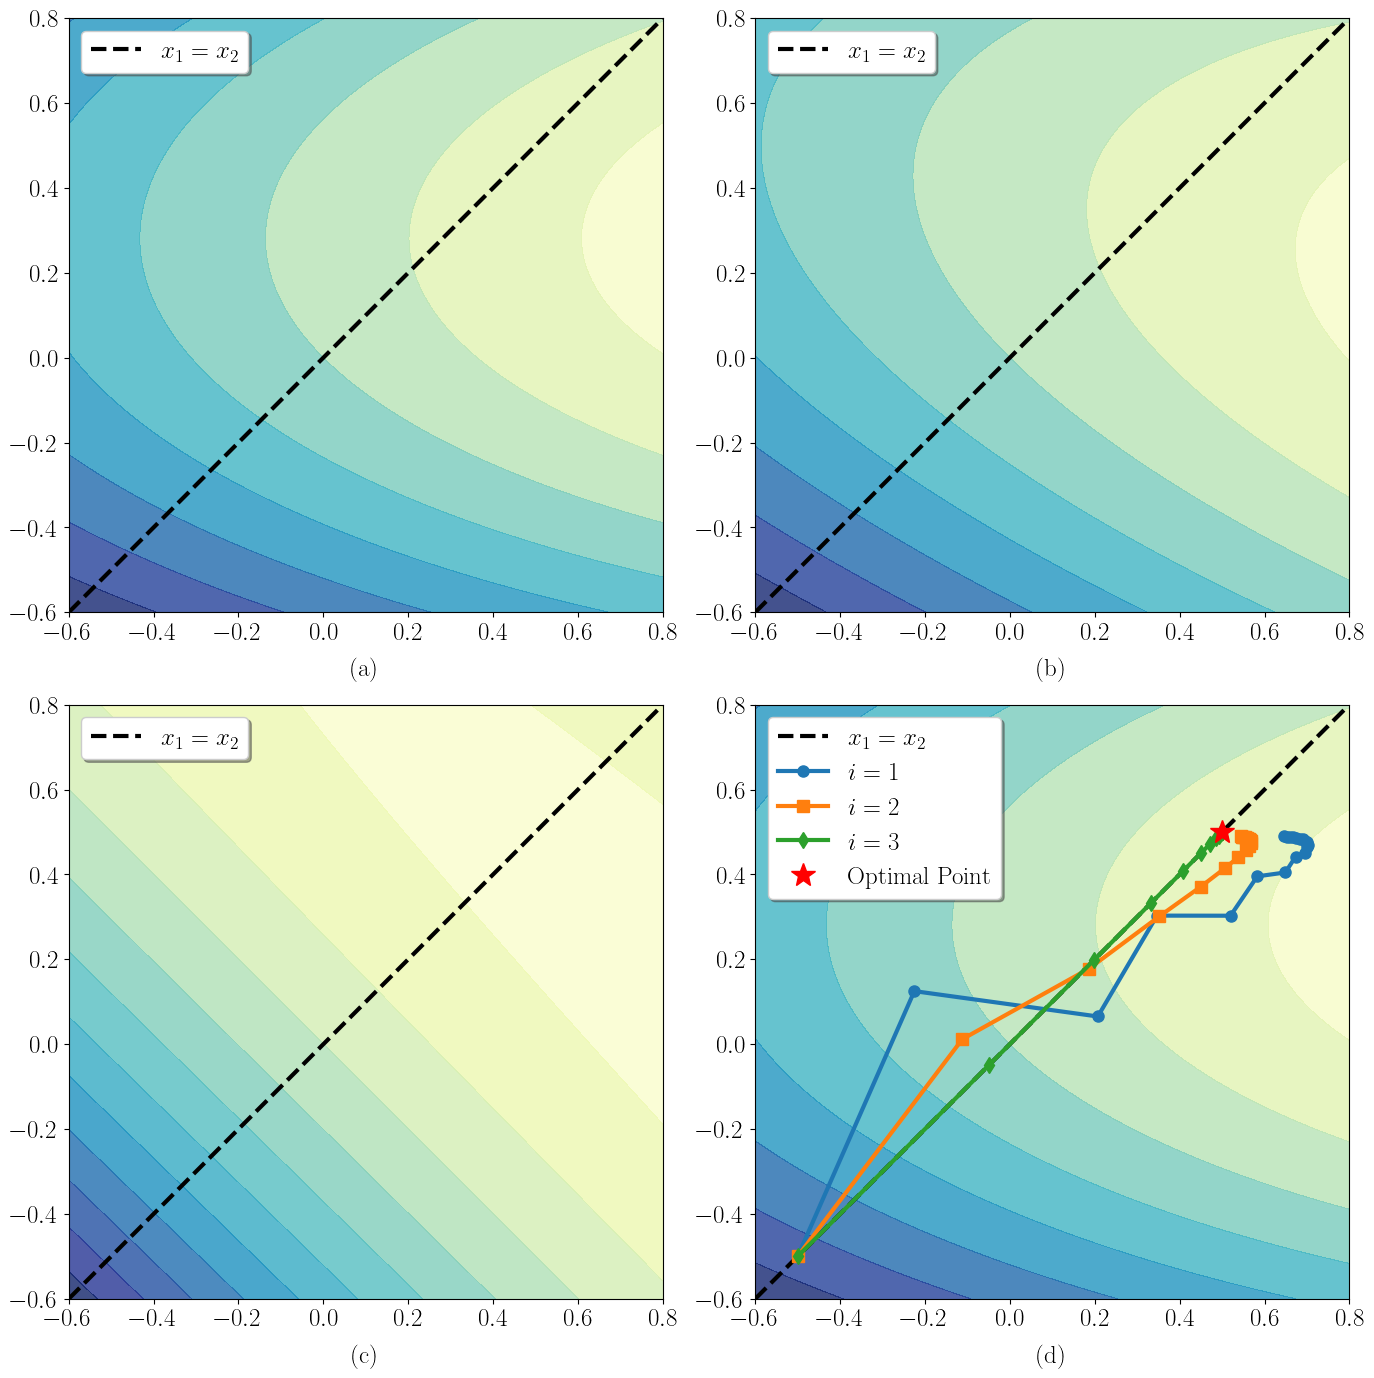

In [48]:
import matplotlib.pyplot as plt
import matplotlib.axes as maxes

plt.rcParams["text.usetex"] = True  # 使用外部 LaTeX 编译器
plt.rcParams["font.family"] = "serif"  # 设置字体为 LaTeX 的默认 serif 字体
plt.rcParams.update({"font.size": 18})

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes_flat = axes.flatten()

titles =["(a)", "(b)", "(c)", "(d)"]

for i in range(3):
    ax: maxes.Axes = axes_flat[i]
    ax.set_aspect(1)
    ax.set_title(titles[i], fontsize=18, y=-0.12)

    ax.contourf(X, Y, Z_list[i], levels=10, cmap="YlGnBu", alpha=0.8)
    ax.plot([-0.6, 0.8], [-0.6, 0.8], "k--", label="$x_{1}=x_{2}$", linewidth=3)
    ax.legend(loc="upper left", fontsize=18, frameon=True, fancybox=True, shadow=True)

ax: maxes.Axes = axes_flat[3]
ax.set_aspect(1)
ax.set_title(titles[3], fontsize=18, y=-0.12)

ax.set_aspect(1)
ax.set_xlim((-0.6, 0.8))
ax.set_ylim((-0.6, 0.8))

ax.plot([-0.6, 0.8], [-0.6, 0.8], "k--", label="$x_{1}=x_{2}$", linewidth=3)
contour = ax.contourf(X, Y, Z, levels=10, cmap="YlGnBu", alpha=0.8)

ax.plot(
    xx_list[0][:, 0], xx_list[0][:, 1], "o-", label="$i=1$", markersize=8, linewidth=3
)
ax.plot(
    xx_list[1][:, 0], xx_list[1][:, 1], "s-", label="$i=2$", markersize=8, linewidth=3
)
ax.plot(
    xx_list[2][:, 0], xx_list[2][:, 1], "d-", label="$i=3$", markersize=8, linewidth=3
)

ax.plot(0.5, 0.5, "r*", markersize=18, label="Optimal Point")

_ = ax.legend(loc="upper left", fontsize=18, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()

## Save the figures

In [49]:
import pathlib

figures_dir = pathlib.Path.cwd() / "precon_illustration"
figures_dir.mkdir(exist_ok=True)

fig.savefig(figures_dir / "precon_illustration.pdf", bbox_inches="tight")
fig.savefig(figures_dir / "precon_illustration.png", bbox_inches="tight", dpi=300)